# Lab 04：從零訓練一個 DDPM（2D 漩渦資料）

對應講義：[第 04 課](../lessons/04_ddpm_training_and_sampling.md)

1. 用 $L_{\text{simple}}$（式 4.9）訓練一個小 MLP 去預測雜訊
2. 用 Algorithm 2（式 4.10）從純雜訊生成樣本，看反向過程一步步「顯影」
3. 看網路在不同 $t$ 猜出的 $\hat x_0$——雜訊很多時它只能猜「平均」
4. 畫出「損失對 $t$」的曲線，理解損失為什麼降不到 0（§2.8）

CPU 約 3 分鐘。

In [1]:
import matplotlib.pyplot as plt
import torch

from diffusion_course.utils import get_device, notebook_logging, set_seed

%matplotlib inline
plt.rcParams["figure.dpi"] = 80
notebook_logging()
set_seed(0)
device = get_device()
print(f"torch {torch.__version__} on {device}")

torch 2.14.0+cpu on cpu


## 1. 資料與模型

ToyMLP with 175,106 parameters


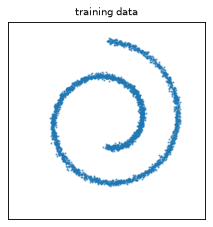

In [2]:
from diffusion_course.data import make_toy_data, toy_batches
from diffusion_course.models import ToyMLP
from diffusion_course.schedules import NoiseSchedule
from diffusion_course.utils import count_parameters
from diffusion_course.viz import new_axes, plot_loss, plot_points

DATASET = "swiss_roll"
TRAIN_STEPS = 5000
BATCH_SIZE = 512

schedule = NoiseSchedule.create("linear", 1000)
model = ToyMLP(data_dim=2, hidden_dim=128, num_blocks=3)
print(f"ToyMLP with {count_parameters(model):,} parameters")

(ax,) = new_axes(1)
plot_points(make_toy_data(DATASET, 3000), ax, "training data")
plt.show()

## 2. 訓練：Algorithm 1

`ddpm_loss` 只有四行：抽 $t$、抽 $\epsilon$、算 $x_t$、對 $\epsilon$ 做 MSE。`train` 是全課共用的訓練迴圈（AdamW ＋ gradient clipping ＋ EMA）。

step 1000/5000  loss 0.3029


step 2000/5000  loss 0.2761


step 3000/5000  loss 0.2734


step 4000/5000  loss 0.2719


step 5000/5000  loss 0.2704


trained in 75s


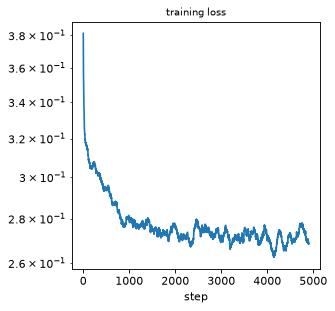

In [3]:
from diffusion_course.ddpm import ddpm_loss
from diffusion_course.training import train

result = train(
    model,
    lambda m, x, y: ddpm_loss(m, schedule, x, y),
    toy_batches(DATASET, BATCH_SIZE),
    num_steps=TRAIN_STEPS,
    lr=1e-3,
    log_every=1000,
)
ema_model = result.sampling_model
print(f"trained in {result.seconds:.0f}s")

(ax,) = new_axes(1, size=4)
plot_loss(result.losses, ax)
plt.show()

損失很快就停在一個正值附近，不會降到 0——原因見本實驗 §5。

## 3. 取樣：Algorithm 2

從 2000 個純雜訊點出發，跑完 1000 步。`save_every=50` 會每 50 步存一次狀態：`trajectory[0]` 是起點 $x_T$，
`trajectory[k]` 是走完第 $k$ 批之後、雜訊等級為 $T - 50k - 1$ 的狀態（最後一個是生成結果）。

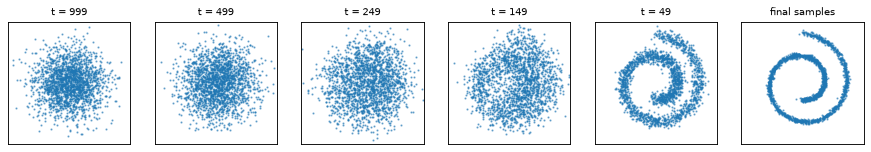

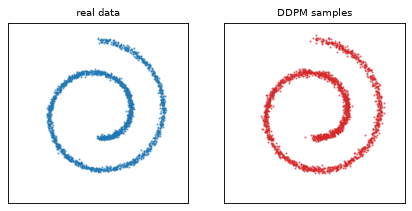

In [4]:
from diffusion_course.ddpm import ddpm_sample

SAVE_EVERY = 50
samples, trajectory = ddpm_sample(ema_model, schedule, (2000, 2), save_every=SAVE_EVERY)
levels = [schedule.num_steps - 1] + [schedule.num_steps - SAVE_EVERY * k - 1 for k in range(1, len(trajectory))]

shown = [0, 10, 15, 17, 19, 20]
axes = new_axes(len(shown), size=2.3)
for ax, k in zip(axes, shown):
    label = "final samples" if levels[k] < 0 else f"t = {levels[k]}"
    plot_points(trajectory[k], ax, label)
plt.show()

axes = new_axes(2)
plot_points(make_toy_data(DATASET, 2000), axes[0], "real data")
plot_points(samples, axes[1], "DDPM samples", color="tab:red")
plt.show()

結構是「由粗到細」出現的：前半段（$t$ 大）只決定了大致的範圍，漩渦要到最後一兩百步才收緊成形。

## 4. 網路在每個 $t$ 猜的 $\hat x_0$

把反向過程中途的 $x_t$ 丟給網路，用 `predict_x0` 換算成「網路心中的乾淨樣本」。
$t$ 大時，從 $x_t$ 幾乎看不出原本是哪一點，最佳猜法是「所有可能性的平均」，所以 $\hat x_0$ 擠在中間；$t$ 越小，猜得越準。
第 05 課會看到這就是 Tweedie 公式：$\hat x_0$ 是條件期望 $\mathbb{E}[x_0 \mid x_t]$。

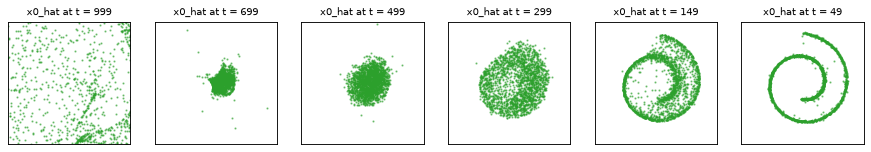

sqrt(alpha_bar) at t = 999: 0.0064


In [5]:
from diffusion_course.ddpm import predict_x0

shown = [0, 6, 10, 14, 17, 19]
axes = new_axes(len(shown), size=2.3)
for ax, k in zip(axes, shown):
    state, t = trajectory[k], torch.full((len(trajectory[k]),), levels[k])
    with torch.no_grad():
        eps = ema_model(state, schedule.timestep_input(t))
    plot_points(predict_x0(schedule, state, t, eps), ax, f"x0_hat at t = {levels[k]}", color="tab:green")
plt.show()
print(f"sqrt(alpha_bar) at t = 999: {schedule.alpha_bars[999].sqrt():.4f}")

**第一格為什麼散得到處都是？** 由 $\hat\epsilon$ 反推 $\hat x_0 = (x_t - \sqrt{1-\bar\alpha_t}\,\hat\epsilon)/\sqrt{\bar\alpha_t}$ 要除以 $\sqrt{\bar\alpha_{999}} \approx 0.006$，
網路輸出裡極小的誤差會被放大一百多倍。這正是講義 §2.9 說的「$\epsilon$-prediction 在高雜訊端數值不穩」，也是影像取樣時要把 $\hat x_0$ 截在 $[-1, 1]$ 的原因。
取樣本身不受影響：(4.10) 的更新只用到 $\hat\epsilon$，那一步 $x_0$ 的係數也非常小。

## 5. 損失對 $t$：為什麼降不到 0

對每個 $t$ 單獨量 $L_{\text{simple}}$（每個 $t$ 用 2 萬個新樣本）。

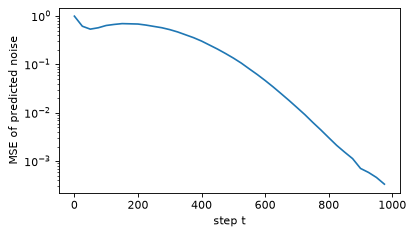

t = 0: 0.998   t = 500: 0.136   t = 975: 0.0003


In [6]:
from diffusion_course.ddpm import q_sample

eval_steps = list(range(0, 1000, 25))
per_step_loss = []
data = make_toy_data(DATASET, 20_000)
with torch.no_grad():
    for step in eval_steps:
        t = torch.full((len(data),), step)
        noise = torch.randn_like(data)
        pred = ema_model(q_sample(schedule, data, t, noise), schedule.timestep_input(t))
        per_step_loss.append(((pred - noise) ** 2).mean().item())

fig, ax = plt.subplots(figsize=(5.5, 3))
ax.plot(eval_steps, per_step_loss)
ax.set_xlabel("step t")
ax.set_ylabel("MSE of predicted noise")
ax.set_yscale("log")
plt.show()
print(f"t = 0: {per_step_loss[0]:.3f}   t = 500: {per_step_loss[20]:.3f}   t = 975: {per_step_loss[-1]:.4f}")

- $t$ 很小：加進去的雜訊比資料本身的抖動（資料自帶標準差 0.05 的雜訊）還小，網路分不出「哪部分是剛加的雜訊」，損失接近 1（等於直接猜 0 的損失）。
- $t$ 很大：$x_t$ 幾乎就是 $\epsilon$，照抄輸入就對了，損失接近 0。

$L_{\text{simple}}$ 是這條曲線對 $t$ 的平均，所以它有一個由資料決定的下限。

## 6. $\sigma_t^2 = \beta_t$ 還是 $\tilde\beta_t$？

Ho 等人說兩者結果相近。用同一份起始雜訊比較：

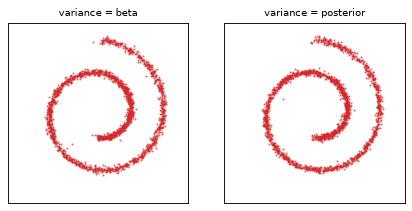

In [7]:
noise = torch.randn(2000, 2)
axes = new_axes(2)
for ax, variance in zip(axes, ["beta", "posterior"]):
    plot_points(ddpm_sample(ema_model, schedule, (2000, 2), variance=variance, noise=noise), ax, f"variance = {variance}", color="tab:red")
plt.show()

## 小結

- DDPM 的訓練就是「猜雜訊的 MSE」，取樣就是把 (4.10) 跑 $T$ 次。
- 生成由粗到細：大 $t$ 決定整體形狀，小 $t$ 修細節；網路在大 $t$ 只能猜平均。
- 損失有由資料決定的下限，不能用它來判斷樣本好壞。

練習題見講義 §5。下一課換個角度：這個「猜雜訊」的網路，其實就是第 02 課的 score。